In [4]:
import numpy as np
import matplotlib.pyplot as plt
import corner

In [5]:
# Definimos funciones f, logL y una propuesta diagonal de C

# Para este caso f sera la ecuacion de la recta, pero puede cambiarse a cualquier otra funcion a la que se desee ajustar los datos
def f_lin(x, theta):
    f=[]
    for i in theta:
        f.append(i[0]*x + i[1])
    return np.array(f)

# Definimos una propuesta de C, donde todos los errores son iguales (1) y no estan correlacionados, es decir la matriz C es lineal
def defC(y):
    return np.eye(len(y))

# Ahora definimos a la funcion logL, para practicidad, haremos primero una funcion que calcule la inversa de C
def Cinv(C):
    return np.linalg.inv(C)

def sigma_nui2(f,func):
    return np.einsum('i,i,ik,ik->i', f ,f ,func, func)
def sigma_nui2i(f,func):
    return f*f*func*func

def total_sigma(sigma, sigma_nui, n_walkers):
    rsigma = sigma_nui+np.sum(sigma**2)
    return rsigma

# Para optimizar el calculo de la minimizacion se calculara chi^2 no solo para los parametros de preba, al mismo tiempo se calculara para los parametros posibles al rededor
# Hacer esto requiere que tengamos el vector de datos en la dimensionalidad adecuada y de f en evaluada en los parametros de alrededor y el central
    
def LogL(y, f, Cinv):
    vec = y-f
    c2 = np.einsum('ij,ijk,ik->i', vec, np.array(Cinv), vec)
    return -c2 #Se calcula de forma matricial pues asi es mucho mas rapido que usando ciclos for

def make_unic_chain(chain, burnpercent, n_walkers):
    chain_no_tail = np.array(chain[0])
    for i in range(n_walkers-1):
        cut = int(len(chain[i+1])*burnpercent)
        chain_no_tail = np.vstack((chain_no_tail,chain[i+1][cut:]))
    return chain_no_tail

In [49]:
data = np.genfromtxt("line-1.dat", delimiter=" ", usemask=False)

In [50]:
upper = [10,10,2]
lower = [-10,-10,0]

initial_theta = np.array([-1.0,4.0,0.01])
sigma = np.array([0.01, 0.01, 0.01])
initial_spread = np.array([0.1,0.1,0.001])

n_walkers = 10
theta = [np.random.normal(initial_theta, initial_spread) for _ in range(n_walkers)]

x = np.array(data[0])
y = np.broadcast_to(data[1], (n_walkers, len(data[1])))

chain = []
C_list = []
logL_nui = []

f = f_lin(x, np.array(theta))

for i in range(n_walkers):
    chain.append([theta[i]])
    C_lin = np.diag(data[2]**2 + sigma_nui2i(np.array(theta).T[2][i], f[i]))
    logL_nui.append(np.sum(C_lin))
    C_list.append(Cinv(C_lin))

n_iter = 100000

logL = LogL(y, f, C_list) - np.array(logL_nui)

for _ in range(n_iter):
    # generamos los parametros propuesta
    theta_prop = [np.random.normal(chain[i][len(chain[i])-1],sigma) for i in range(n_walkers)]
    param_acc = True
    for k in range(len(theta)):
        for j in range(len(theta[k])):
            param_acc = param_acc and bool(theta_prop[k][j]<upper[j]) and bool(theta_prop[k][j]>lower[j])
    if param_acc:
        # calculamos logL de los parametros propuestos
        f_prop = f_lin(x, np.array(theta_prop))

        C_list_prop = []
        logL_nui = []
        for j in range(n_walkers):
            C_lin = np.diag(data[2]**2 + sigma_nui2i(np.array(theta_prop).T[2][j], f_prop[j]))
            logL_nui.append(np.sum(C_lin))
            C_list_prop.append(Cinv(C_lin))
        
        logL_prop = LogL(y, f_prop, C_list_prop) - np.array(logL_nui)
        for i in range(n_walkers):
            if logL_prop[i]>logL[i]:
                chain[i].append(theta_prop[i])
                logL[i] = logL_prop[i]
                C_list[i] = C_list_prop[i]
            else:
                p_acc = np.random.uniform()
                crit = (logL_prop[i] - logL[i])
                crit2 = np.log(p_acc)
                if crit>crit2:
                    chain.append(theta_prop[i])
                    logL[i] = logL_prop[i]
                    C_list[i] = C_list_prop[i]

In [51]:
chain_no_tail = make_unic_chain(chain, 0.9, n_walkers)

/var/folders/w2/bc_hd1792ng0j46hmt8zbzcr0000gp/T/ipykernel_678/2392514850.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot.show()


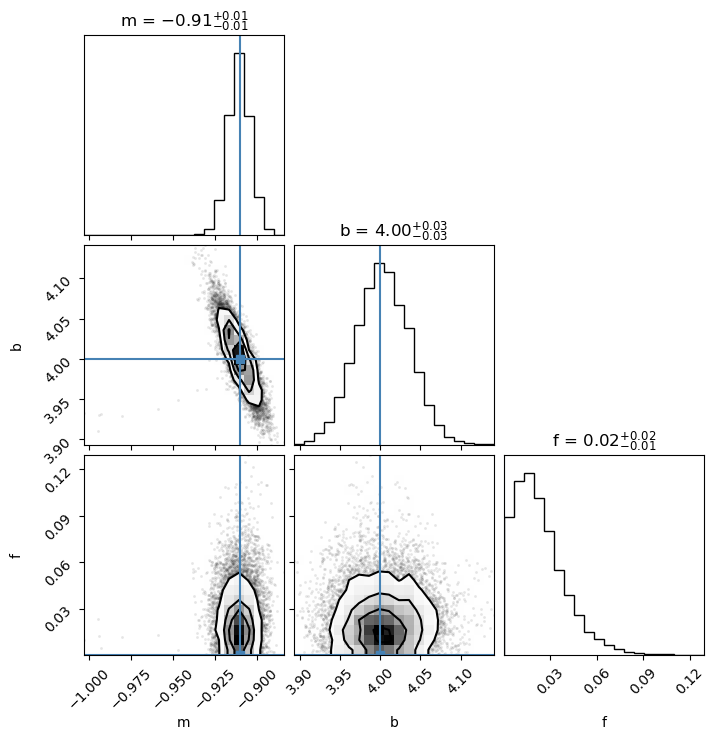

In [52]:
params = ['m', 'b', 'f']
param_array_truths = [-0.91,4.0,0.0]
plot = corner.corner(chain_no_tail, labels=params, show_titles=True, truths=param_array_truths)
plt.savefig('data_1.png',format='png')
plot.show()

In [53]:
print('m = ' + str(round(np.median(chain_no_tail.T[0]),5)))
print('b = ' + str(round(np.median(chain_no_tail.T[1]),5)))
print('f = ' + str(round(np.median(chain_no_tail.T[2]),5)))

m = -0.91061
b = 4.00288
f = 0.02004


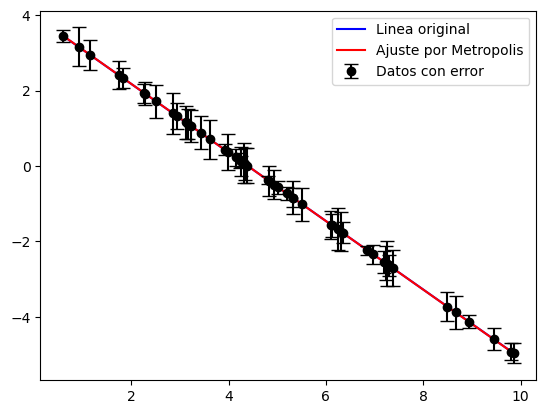

In [54]:
y_ajuste = np.median(chain_no_tail.T[0])*x + np.median(chain_no_tail.T[1])
y_real = -0.91*x + 4.0
plt.plot(x, y_real, color = 'blue', label='Linea original')
plt.plot(x, y_ajuste, color = 'red', label='Ajuste por Metropolis')
plt.errorbar(x, data[1], yerr=data[2], fmt='o', color='black', 
             ecolor='black', capsize=5, label='Datos con error')
plt.legend()

In [27]:
data = np.genfromtxt("line-2.dat", delimiter=" ", usemask=False)

In [41]:
upper = [10,10,2]
lower = [-10,-10,0]

initial_theta = np.array([-1.0,4.0,0.01])
sigma = np.array([0.01, 0.01, 0.01])
initial_spread = np.array([0.1,0.1,0.001])

n_walkers = 10
theta = [np.random.normal(initial_theta, initial_spread) for _ in range(n_walkers)]

x = np.array(data[0])
y = np.broadcast_to(data[1], (n_walkers, len(data[1])))

chain = []
C_list = []
logL_nui = []
f = f_lin(x, np.array(theta))
for i in range(n_walkers):
    chain.append([theta[i]])
    C_lin = np.diag(data[2]**2 + sigma_nui2i(np.array(theta).T[2][i], f[i]))
    logL_nui.append(np.sum(C_lin))
    C_list.append(Cinv(C_lin))

n_iter = 100000

logL = LogL(y, f, C_list) - np.array(logL_nui)

for _ in range(n_iter):
    # generamos los parametros propuesta
    theta_prop = [np.random.normal(chain[i][len(chain[i])-1],sigma) for i in range(n_walkers)]
    param_acc = True
    for k in range(len(theta)):
        for j in range(len(theta[k])):
            param_acc = param_acc and bool(theta_prop[k][j]<upper[j]) and bool(theta_prop[k][j]>lower[j])
    if param_acc:
        # calculamos logL de los parametros propuestos
        f_prop = f_lin(x, np.array(theta_prop))

        C_list_prop = []
        logL_nui = []
        for j in range(n_walkers):
            C_lin = np.diag(data[2]**2 + sigma_nui2i(np.array(theta_prop).T[2][j], f_prop[j]))
            logL_nui.append(np.sum(C_lin))
            C_list_prop.append(Cinv(C_lin))
        
        logL_prop = LogL(y, f_prop, C_list_prop) - np.array(logL_nui)
        for i in range(n_walkers):
            if logL_prop[i]>logL[i]:
                chain[i].append(theta_prop[i])
                logL[i] = logL_prop[i]
                C_list[i] = C_list_prop[i]
            else:
                p_acc = np.random.uniform()
                crit = (logL_prop[i] - logL[i])
                crit2 = np.log(p_acc)
                if crit>crit2:
                    chain.append(theta_prop[i])
                    logL[i] = logL_prop[i]
                    C_list[i] = C_list_prop[i]

In [46]:
chain_no_tail = make_unic_chain(chain, 0.999, n_walkers)

/var/folders/w2/bc_hd1792ng0j46hmt8zbzcr0000gp/T/ipykernel_678/124357563.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot.show()


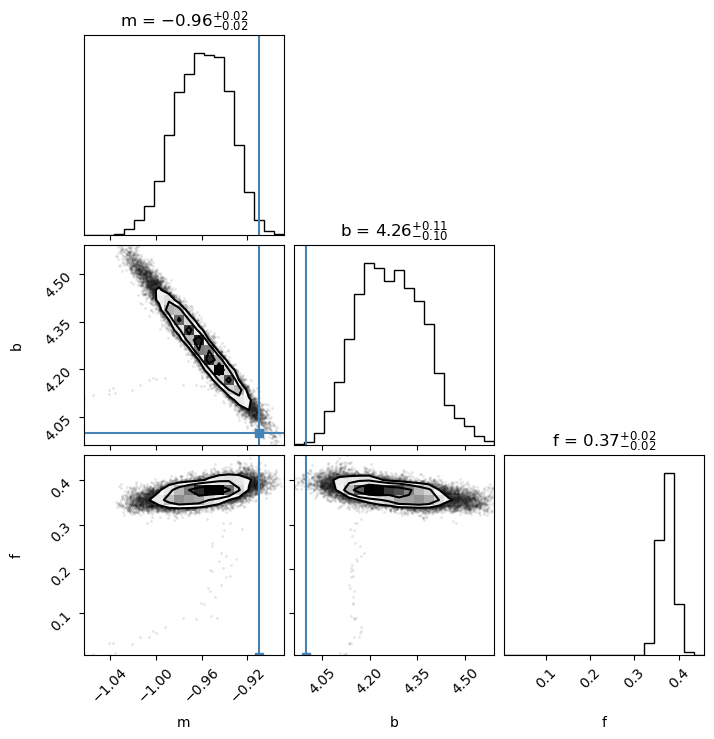

In [47]:
params = ['m', 'b', 'f']
param_array_truths = [-0.91,4.0,0.0]
plot = corner.corner(chain_no_tail, labels=params, show_titles=True, truths=param_array_truths)
plt.savefig('data_2.png',format='png')
plot.show()

In [48]:
print('m = ' + str(round(np.median(chain_no_tail.T[0]),5)))
print('b = ' + str(round(np.median(chain_no_tail.T[1]),5)))
print('f = ' + str(round(np.median(chain_no_tail.T[2]),5)))

m = -0.95878
b = 4.26408
f = 0.37276


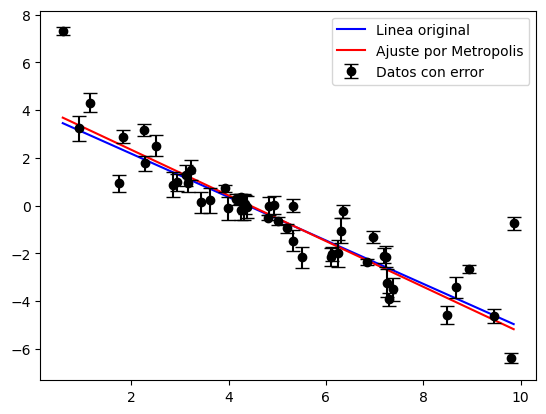

In [45]:
y_ajuste = np.median(chain_no_tail.T[0])*x + np.median(chain_no_tail.T[1])
y_real = -0.91*x + 4.0
plt.plot(x, y_real, color = 'blue', label='Linea original')
plt.plot(x, y_ajuste, color = 'red', label='Ajuste por Metropolis')
plt.errorbar(x, data[1], yerr=data[2], fmt='o', color='black', 
             ecolor='black', capsize=5, label='Datos con error')
plt.legend()